# EMOS Coding Lab: Automatic Coding with Text Similarity

In this lab we build a small automatic coding system step by step.

The task is simple to state: given a short text query, suggest the most appropriate classification code.

We will focus on transparency rather than performance. At each step we ask: what information do we have, what transformation are we applying, and how can we validate the result?

## 1. Introduction

**Automatic coding** means assigning a classification code to a text description. In Official Statistics, this can support tasks such as coding economic activities, occupations, products, or causes of death.

A useful automatic coding system should not only output a code. It should also help us understand why that code was suggested, how confident the system is, and where human validation is needed.

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loading import load_labelled_queries, load_teaching_sample, load_ateco_descriptors, create_teaching_sample
from src.descriptors import build_descriptors
from src.embeddings import compute_tfidf_embeddings, compute_centroid_embeddings, load_embedding_model, compute_sentence_embeddings
from src.similarity import compute_similarity_matrix, get_top_k_predictions, add_predictions_to_queries
from src.evaluation import summarize_accuracy, get_error_examples

## 2. Data loading

We use labelled queries as examples of texts that need to be coded. Each query already has a true code, so we can evaluate our automatic suggestions.

For the classroom exercise we use a small reproducible sample prepared from the raw data. The sample keeps only multi-word queries and removes duplicated query/code pairs. This keeps the notebook fast and makes the examples easier to inspect.

In [ ]:
raw_queries = load_labelled_queries()
raw_queries.head()

### Data exploration: Distribution of ATECO codes

Before building the automatic coding system, let's explore the structure of the labelled data. The ATECO classification is hierarchical:

- **Sezione** (section): first level, e.g., "47"
- **Divisione** (division): second level, e.g., "47.10"
- **Classe** (class): full code, e.g., "47.10.1"

This hierarchy reflects the logical structure of economic activities. We need to understand how codes are distributed in our data: are they balanced? Are they concentrated in few sections?

This information helps us predict potential challenges for an automatic coding system (e.g., rare codes are harder to predict accurately).

In [ ]:
# Extract hierarchical levels from ATECO codes
raw_queries['sezione'] = raw_queries['true_code'].str.split('.').str[0]
raw_queries['divisione'] = raw_queries['true_code'].str.split('.').str[:2].str.join('.')

# Compute distribution statistics
distribuzione_codici = raw_queries['true_code'].value_counts().sort_values(ascending=False)
distribuzione_sezioni = raw_queries['sezione'].value_counts()
distribuzione_divisioni = raw_queries['divisione'].value_counts()

print("="*70)
print("ATECO CLASSIFICATION STRUCTURE AND DISTRIBUTION")
print("="*70)
print(f"\nDataset size: {len(raw_queries):,} queries")
print(f"Unique full codes (classe): {raw_queries['true_code'].nunique()}")
print(f"Unique divisions (divisione): {raw_queries['divisione'].nunique()}")
print(f"Unique sections (sezione): {raw_queries['sezione'].nunique()}")

print("\n--- TOP 10 FULL CODES ---")
print(distribuzione_codici.head(10))

print("\n--- TOP 10 SECTIONS ---")
print(distribuzione_sezioni.head(10))

print("\n--- BALANCE ANALYSIS ---")
print(f"Most frequent code: {distribuzione_codici.index[0]} with {distribuzione_codici.iloc[0]} queries")
print(f"Least frequent code: {distribuzione_codici.index[-1]} with {distribuzione_codici.iloc[-1]} queries")
print(f"Mean queries per code: {distribuzione_codici.mean():.1f}")
print(f"Median queries per code: {distribuzione_codici.median():.1f}")

print("\nCode frequency distribution:")
print(f"  - Codes with ≥100 queries: {(distribuzione_codici >= 100).sum()}")
print(f"  - Codes with 50-100 queries: {((distribuzione_codici >= 50) & (distribuzione_codici < 100)).sum()}")
print(f"  - Codes with 10-50 queries: {((distribuzione_codici >= 10) & (distribuzione_codici < 50)).sum()}")
print(f"  - Codes with <10 queries: {(distribuzione_codici < 10).sum()}")

In [ ]:
# Visualize the hierarchical structure
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Top sections
top_sezioni = distribuzione_sezioni.head(15)
axes[0].barh(range(len(top_sezioni)), top_sezioni.values, color='steelblue')
axes[0].set_yticks(range(len(top_sezioni)))
axes[0].set_yticklabels(top_sezioni.index)
axes[0].set_xlabel('Number of queries')
axes[0].set_title('Top 15 ATECO sections (sezione)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Top divisions
top_divisioni = distribuzione_divisioni.head(15)
axes[1].barh(range(len(top_divisioni)), top_divisioni.values, color='coral')
axes[1].set_yticks(range(len(top_divisioni)))
axes[1].set_yticklabels(top_divisioni.index)
axes[1].set_xlabel('Number of queries')
axes[1].set_title('Top 15 ATECO divisions (divisione)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Plot 3: For each section, how evenly are queries spread across its codes?
# Each box shows the distribution of "queries per code" within a section.
# A wide box = unbalanced section (some codes get many queries, others very few).
# A narrow box = balanced section (queries are spread evenly).
sezione_stats = []
sezione_labels = []
for sezione in distribuzione_sezioni.head(10).index:
    # Count queries per code within this section
    queries_per_code = raw_queries[raw_queries['sezione'] == sezione]['true_code'].value_counts().values
    sezione_stats.append(queries_per_code)
    sezione_labels.append(sezione)

axes[2].boxplot(sezione_stats, tick_labels=sezione_labels)
axes[2].set_ylabel('Number of queries per code\n(each dot = one ATECO code)')
axes[2].set_title('Within-section balance:\nhow evenly are queries spread across codes?')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'ateco_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to: outputs/ateco_hierarchy.png")

### Query length analysis

Each query has a `n_words` column: the number of words in the description.

Query length matters for automatic coding:
- **Short queries** (1–2 words) are often ambiguous: "legno" or "pizza" could belong to many different codes.
- **Longer queries** carry more context and are generally easier to classify correctly.

We explore three questions:
1. How are query lengths distributed overall?
2. Do some ATECO sections tend to have shorter or longer descriptions?
3. Is there a relationship between query length and how often a code appears in the data?

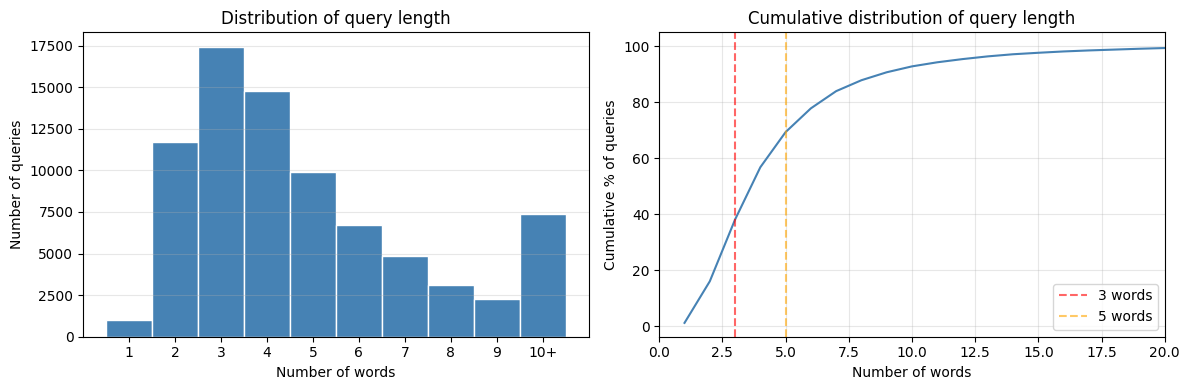

Query length summary:
count    79058.0
mean         5.1
std          3.5
min          1.0
25%          3.0
50%          4.0
75%          6.0
max         40.0
Name: n_words, dtype: float64

Queries with 1 word:    1,003 (1.3%)
Queries with ≤ 3 words: 30,152 (38.1%)
Queries with > 5 words: 24,234 (30.7%)


In [53]:
# --- Analysis 1: Overall distribution of query length ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of n_words
# We cap at 10 words to keep the chart readable (very long queries are rare)
capped = raw_queries['n_words'].clip(upper=10)
axes[0].hist(capped, bins=range(1, 12), align='left', color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 11))
axes[0].set_xticklabels([str(i) if i < 10 else '10+' for i in range(1, 11)])
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of queries')
axes[0].set_title('Distribution of query length')
axes[0].grid(axis='y', alpha=0.3)

# Right: cumulative percentage — helps answer "what fraction of queries are ≤ k words?"
sorted_lengths = raw_queries['n_words'].sort_values()
cumulative_pct = (sorted_lengths.rank(method='max') / len(sorted_lengths) * 100)
axes[1].plot(sorted_lengths.values, cumulative_pct.values, color='steelblue')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='3 words')
axes[1].axvline(x=5, color='orange', linestyle='--', alpha=0.6, label='5 words')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Cumulative % of queries')
axes[1].set_title('Cumulative distribution of query length')
axes[1].set_xlim(0, 20)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Query length summary:")
print(raw_queries['n_words'].describe().round(1))
print(f"\nQueries with 1 word:    {(raw_queries['n_words'] == 1).sum():,} ({(raw_queries['n_words'] == 1).mean():.1%})")
print(f"Queries with ≤ 3 words: {(raw_queries['n_words'] <= 3).sum():,} ({(raw_queries['n_words'] <= 3).mean():.1%})")
print(f"Queries with > 5 words: {(raw_queries['n_words'] > 5).sum():,} ({(raw_queries['n_words'] > 5).mean():.1%})")

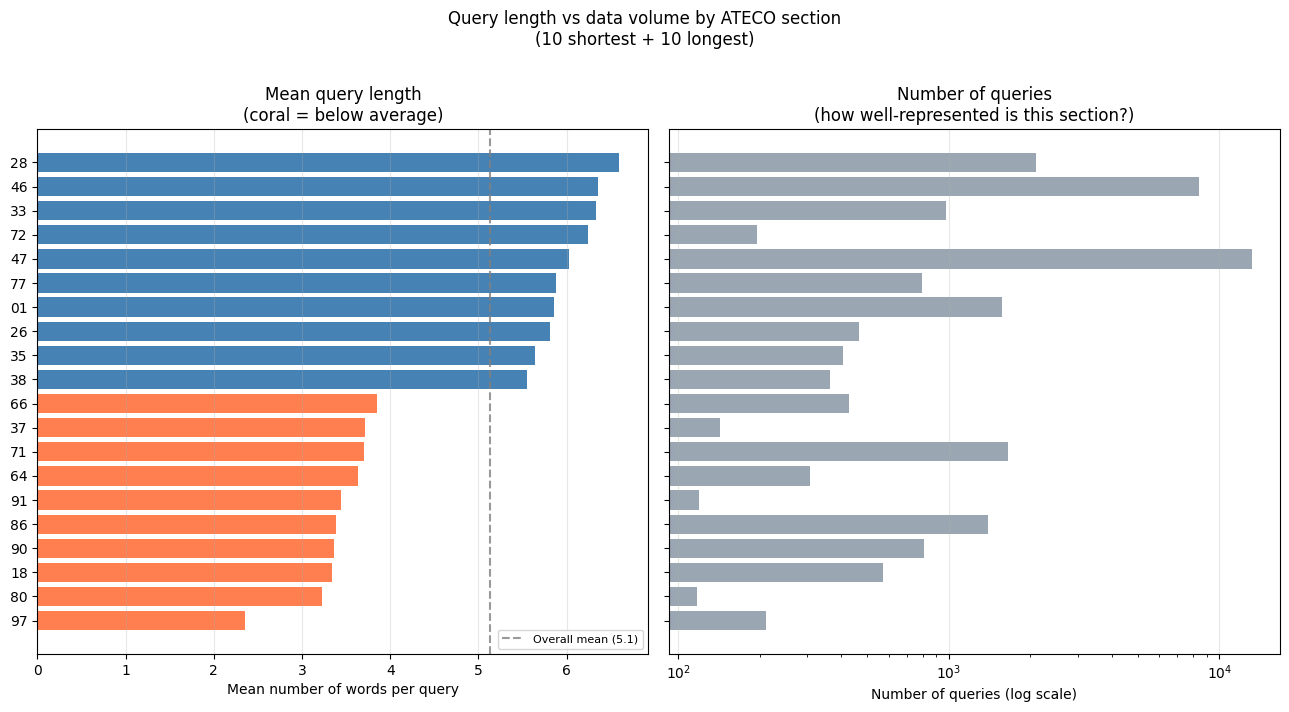

In [56]:
# --- Analysis 2: Average query length by ATECO section ---
# Do some sections tend to have longer or shorter descriptions?
# For example, retail trade (47) often uses product names (short),
# while professional services (74) may use longer activity descriptions.
#
# We show BOTH dimensions side by side:
#   Left panel:  mean query length  → how informative is the text?
#   Right panel: number of queries  → how well-represented is the section?
# Reading both together helps us identify sections that may be hard to classify.

length_by_sezione = (
    raw_queries.groupby('sezione')['n_words']
    .agg(mean='mean', count='count')
    .query('count >= 100')
    .sort_values('mean', ascending=True)
)

# Keep 10 shortest + 10 longest average query sections
top_n = pd.concat([
    length_by_sezione.head(10),
    length_by_sezione.tail(10),
])

overall_mean = raw_queries['n_words'].mean()
colors = ['coral' if v < overall_mean else 'steelblue' for v in top_n['mean']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

# Left: mean query length
ax1.barh(range(len(top_n)), top_n['mean'], color=colors)
ax1.set_yticks(range(len(top_n)))
ax1.set_yticklabels(top_n.index)
ax1.axvline(x=overall_mean, color='gray', linestyle='--', alpha=0.8,
            label=f'Overall mean ({overall_mean:.1f})')
ax1.set_xlabel('Mean number of words per query')
ax1.set_title('Mean query length\n(coral = below average)')
ax1.legend(fontsize=8)
ax1.grid(axis='x', alpha=0.3)

# Right: number of queries (log scale because range is wide)
ax2.barh(range(len(top_n)), top_n['count'], color='slategray', alpha=0.7)
ax2.set_xlabel('Number of queries (log scale)')
ax2.set_title('Number of queries\n(how well-represented is this section?)')
ax2.set_xscale('log')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Query length vs data volume by ATECO section\n(10 shortest + 10 longest)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**How to read this chart:**

- **Left panel**: sections with longer average queries (blue) give the classifier more text to work with → generally easier to code correctly.
- **Right panel**: sections with fewer queries (shorter bars) are less represented in the data → the classifier has seen fewer examples of those codes.

**Sections that appear short on the left AND short on the right are doubly difficult**: the queries are ambiguous, and there are few of them to work with.

> **Discussion question**: can you identify any section in this chart that combines both problems? What would you suggest to improve the system's performance on those sections?

### A complexity indicator for ATECO sections

The previous analyses suggest three key factors that may influence how difficult it is for the classifier to assign the correct code:

1. **Query length** — longer descriptions carry more information
2. **Data volume** — sections with more queries give the model more signal
3. **Code density** — sections with many fine-grained codes but few queries per code are harder to discriminate between

We define code density as $d_s = k_s / n_s$, where $k_s$ is the number of unique codes in section $s$. A high value means the classifier must choose among many categories with little data for each.

We combine all three dimensions into a single **complexity score**.

**Step 1 — Normalise each dimension to $[0, 1]$:**

$$\hat{l}_s = \frac{\bar{l}_s - \min_s \bar{l}_s}{\max_s \bar{l}_s - \min_s \bar{l}_s}$$

$$\hat{n}_s = \frac{\log_{10}(n_s) - \min_s \log_{10}(n_s)}{\max_s \log_{10}(n_s) - \min_s \log_{10}(n_s)}$$

$$\hat{d}_s = \frac{d_s - \min_s d_s}{\max_s d_s - \min_s d_s}$$

where $\bar{l}_s$ is the mean query length, $n_s$ is the total number of queries, and $d_s = k_s / n_s$ is the code density for section $s$.

**Step 2 — Combine into a complexity score:**

High $\hat{l}_s$ and high $\hat{n}_s$ both reduce complexity (more information, more data). High $\hat{d}_s$ increases complexity (many codes, little data per code):

$$\text{complexity}_s = \frac{(1 - \hat{l}_s) + (1 - \hat{n}_s) + \hat{d}_s}{3}$$


A score near **1** means: short queries, few observations, and many codes to choose from → *hard to classify*.  > This is a working hypothesis. We will verify it in Section 6 by checking whether accuracy actually drops for sections predicted to be hard.

A score near **0** means: long queries, many observations, and few codes → *easy to classify*.

**Step 3 — Assign tiers** using quartiles: *Easy / Moderate / Hard / Very Hard*.

In [ ]:
import numpy as np

# Build a per-section profile (only sections with ≥ 100 queries for stable estimates)
section_profile = (
    raw_queries.groupby('sezione')['n_words']
    .agg(mean_length='mean', n_queries='count')
    .query('n_queries >= 100')
    .reset_index()
)

# Add number of unique codes per section
n_unique_codes = raw_queries.groupby('sezione')['true_code'].nunique().rename('n_unique_codes')
section_profile = section_profile.join(n_unique_codes, on='sezione')

# Code density: how many unique codes per query — high = many fine-grained categories, little data per code
section_profile['density'] = section_profile['n_unique_codes'] / section_profile['n_queries']

# Step 1: normalise each dimension to [0, 1]
l_min, l_max = section_profile['mean_length'].min(), section_profile['mean_length'].max()
section_profile['length_norm'] = (section_profile['mean_length'] - l_min) / (l_max - l_min)

log_n = np.log10(section_profile['n_queries'])
section_profile['freq_norm'] = (log_n - log_n.min()) / (log_n.max() - log_n.min())

d_min, d_max = section_profile['density'].min(), section_profile['density'].max()
section_profile['density_norm'] = (section_profile['density'] - d_min) / (d_max - d_min)

# Step 2: complexity score
# High length_norm and freq_norm → easier (subtract from 1)
# High density_norm → harder (add directly)
section_profile['complexity'] = (
    (1 - section_profile['length_norm'])
    + (1 - section_profile['freq_norm'])
    + section_profile['density_norm']
) / 3

# Step 3: assign tiers based on quartiles
q25, q50, q75 = section_profile['complexity'].quantile([0.25, 0.50, 0.75])

def assign_tier(score):
    if score <= q25:
        return 'Easy'
    elif score <= q50:

        return 'Moderate'    print(f"{row['sezione']:<10} {row['mean_length']:>12.2f} {row['n_queries']:>10,} {row['n_unique_codes']:>8} {row['density']:>9.3f} {row['complexity']:>12.3f}   {row['tier']}")

    elif score <= q75:for _, row in section_profile.sort_values('complexity', ascending=False).head(20).iterrows():

        return 'Hard'print("-"*80)

    else:print(f"{'Section':<10} {'Mean length':>12} {'N queries':>10} {'N codes':>8} {'Density':>9} {'Complexity':>12} {'Tier'}")

        return 'Very Hard'print("="*80)

print("SECTION COMPLEXITY RANKING (top 20)")

section_profile['tier'] = section_profile['complexity'].apply(assign_tier)# Show the ranking — most complex sections at the top


In [ ]:
# Quadrant plot: each dot is one ATECO section
# X axis = mean query length, Y axis = log10(n_queries)
# Dashed lines = medians → define the four quadrants
# Color = complexity tier

tier_colors = {
    'Easy':      'steelblue',
    'Moderate':  'mediumseagreen',
    'Hard':      'orange',
    'Very Hard': 'coral',
}
tier_order = ['Easy', 'Moderate', 'Hard', 'Very Hard']

median_length  = section_profile['mean_length'].median()
median_log_n   = np.log10(section_profile['n_queries']).median()

fig, ax = plt.subplots(figsize=(9, 7))

for tier in tier_order:
    group = section_profile[section_profile['tier'] == tier]
    ax.scatter(
        group['mean_length'],
        np.log10(group['n_queries']),
        label=tier,
        color=tier_colors[tier],
        s=80, alpha=0.85, zorder=3,
    )

# Label the 4 most complex and 4 easiest sections
for _, row in section_profile.nlargest(4, 'complexity').iterrows():
    ax.annotate(row['sezione'],
                xy=(row['mean_length'], np.log10(row['n_queries'])),
                xytext=(6, 3), textcoords='offset points', fontsize=8)
for _, row in section_profile.nsmallest(4, 'complexity').iterrows():
    ax.annotate(row['sezione'],
                xy=(row['mean_length'], np.log10(row['n_queries'])),
                xytext=(6, 3), textcoords='offset points', fontsize=8)

# Quadrant dividers
ax.axvline(x=median_length, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=median_log_n,  color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmin + 0.1, ymax - 0.05, 'Short text + few data\n→ Hardest',
        fontsize=8, color='coral',     va='top')
ax.text(xmax - 0.1, ymin + 0.05, 'Long text + many data\n→ Easiest',
        fontsize=8, color='steelblue', va='bottom', ha='right')

ax.set_xlabel('Mean query length (words)')
ax.set_ylabel('$\\log_{10}$(number of queries)')
ax.set_title('Section complexity map\n(each dot = one ATECO section with ≥ 100 queries)')
ax.legend(title='Complexity tier', loc='lower right')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nTier distribution:")
print(section_profile['tier'].value_counts().reindex(tier_order))

In [ ]:
# --- Analysis 3: Query length vs code frequency ---
# Are rare codes associated with shorter queries?
# If yes, this helps explain why they are harder to classify:
# fewer examples AND less informative text.

# For each ATECO code, compute: how many queries it has, and the average query length
code_stats = (
    raw_queries.groupby('true_code')['n_words']
    .agg(mean_length='mean', count='count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

# Use log scale on x-axis because frequencies span a wide range (1 to 1600)
ax.scatter(
    code_stats['count'],
    code_stats['mean_length'],
    alpha=0.3,
    s=20,
    color='steelblue'
)
ax.set_xscale('log')
ax.set_xlabel('Number of queries for this code (log scale)')
ax.set_ylabel('Average query length (words)')
ax.set_title('Query length vs code frequency\n(each dot = one ATECO code)')
ax.grid(alpha=0.3)

# Add a trend line to make the pattern visible
import numpy as np
log_counts = np.log10(code_stats['count'])
coeffs = np.polyfit(log_counts, code_stats['mean_length'], deg=1)
x_range = np.linspace(log_counts.min(), log_counts.max(), 100)
ax.plot(10**x_range, np.polyval(coeffs, x_range), color='red', linewidth=2, label='Trend')
ax.legend()

plt.tight_layout()
plt.show()

# Correlation summary
corr = code_stats['count'].corr(code_stats['mean_length'])
print(f"Correlation between code frequency and mean query length: {corr:.3f}")
print("\nInterpretation: a positive value means that rare codes tend to have shorter queries.")

In [ ]:
# The sample was created with create_teaching_sample(raw_queries, min_words=3, sample_size=500).
sample_queries = load_teaching_sample()
sample_queries.head(10)

In [ ]:
sample_queries.shape, sample_queries["true_code"].nunique()

In [ ]:
# Compare the section distribution between raw data and the teaching sample.
# If sampling was proportional, the two bars should look similar in shape.
# Large differences would indicate a bias: some sections over- or under-represented.

sample_queries['sezione'] = sample_queries['true_code'].str.split('.').str[0]

# Normalize to proportions so the two datasets are comparable despite different sizes
raw_sezione_pct = (raw_queries['sezione'].value_counts(normalize=True) * 100).rename('raw (%)')
sample_sezione_pct = (sample_queries['sezione'].value_counts(normalize=True) * 100).rename('sample (%)')

# Align on the same sections and fill missing values with 0
comparison = pd.concat([raw_sezione_pct, sample_sezione_pct], axis=1).fillna(0)
comparison = comparison.sort_values('raw (%)', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(comparison))
width = 0.4
ax.bar([i - width/2 for i in x], comparison['raw (%)'], width=width, label=f'Raw ({len(raw_queries):,} queries)', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], comparison['sample (%)'], width=width, label=f'Sample ({len(sample_queries):,} queries)', color='coral', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=45)
ax.set_ylabel('Share of queries (%)')
ax.set_title('Section distribution: raw data vs sample\n(Top 20 sections by raw frequency)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the numerical comparison for the largest differences
comparison['difference (pp)'] = (comparison['sample (%)'] - comparison['raw (%)']).round(2)
print("\nTop sections by absolute difference (percentage points):")
print(comparison.reindex(comparison['difference (pp)'].abs().sort_values(ascending=False).index).head(10))

## 3. Classification and descriptors

A classification system is a structured list of possible codes. A code is not just a number: it represents a statistical category.

To use text similarity, we need text descriptions for the target codes. Here there is one important modelling choice: the labelled data is at 5-digit level, while the ATECO descriptor file contains more detailed 6-digit descriptors.

We test two simple strategies:

- `CONCAT`: combine all detailed descriptors belonging to the same 5-digit code into one text.
- `CENTROID`: embed each detailed descriptor separately, then average the vectors for each 5-digit code.

In [ ]:
DESCRIPTOR_METHOD = "CONCAT"  # Try also: "CENTROID"

raw_descriptors = load_ateco_descriptors()
descriptor_table = build_descriptors(raw_descriptors, method=DESCRIPTOR_METHOD)

# We keep the full set of candidate target codes. This is important:
# in a real coding task, the system should not know the true label in advance.
sample_queries = sample_queries[
    sample_queries["true_code"].isin(descriptor_table["code"])
].reset_index(drop=True)

pd.set_option("display.max_colwidth", 150)

descriptor_table.head(40)

In [ ]:
descriptor_table.shape

## 4. Embeddings

An **embedding** is a numerical representation of text. Intuitively, it places texts in a space where texts with similar meaning should be closer together.

Many modern embedding models are shared through **Hugging Face**, an online hub for machine learning models, datasets, and demos. In practice, this means we do not need to train a language model from scratch: we can reuse a pre-trained multilingual model and apply it to our coding task.

For reliability in a classroom setting, we start with a simple TF-IDF representation. It is not a modern semantic embedding model, but it makes the same similarity workflow visible and runs quickly.

If the sentence-transformers model is installed and available, the optional cell below switches to a multilingual semantic embedding model from Hugging Face.

In [ ]:
query_vectors, descriptor_vectors = compute_tfidf_embeddings(
    sample_queries["query"],
    descriptor_table["descriptor_text"],
)

if DESCRIPTOR_METHOD == "CENTROID":
    target_codes, target_vectors = compute_centroid_embeddings(
        descriptor_vectors,
        descriptor_table["code"],
    )
else:
    target_codes = descriptor_table["code"].tolist()
    target_vectors = descriptor_vectors

query_vectors.shape, target_vectors.shape, len(target_codes)

In [ ]:
# Optional: use a multilingual sentence embedding model instead of TF-IDF.
# The selected model is downloaded from Hugging Face the first time it is used.
# Larger models may need more memory, more time, or a GPU/cloud environment.

EMBEDDING_MODELS = [
    {
        "model_id": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "trust_remote_code": False,
        "note": "small classroom default",
    },
    {
        "model_id": "BAAI/bge-m3",
        "trust_remote_code": False,
        "note": "strong multilingual embedding model",
    },
    {
        "model_id": "intfloat/multilingual-e5-base",
        "trust_remote_code": False,
        "note": "multilingual E5 base model",
    },
    {
        "model_id": "Alibaba-NLP/gte-multilingual-base",
        "trust_remote_code": True,
        "note": "requires trusting custom model code",
    },
    {
        "model_id": "Qwen/Qwen3-Embedding-4B",
        "trust_remote_code": True,
        "note": "larger model; better suited to GPU/cloud testing",
    },
]

selected_model = EMBEDDING_MODELS[0]
selected_model

In [ ]:
# Uncomment this cell to replace TF-IDF vectors with sentence embeddings.

model = load_embedding_model(
    selected_model["model_id"],
    trust_remote_code=selected_model["trust_remote_code"],
)
query_vectors = compute_sentence_embeddings(sample_queries["query"], model)
descriptor_vectors = compute_sentence_embeddings(descriptor_table["descriptor_text"], model)

if DESCRIPTOR_METHOD == "CENTROID":
    target_codes, target_vectors = compute_centroid_embeddings(
        descriptor_vectors,
        descriptor_table["code"],
    )
else:
    target_codes = descriptor_table["code"].tolist()
    target_vectors = descriptor_vectors

## 5. Similarity-based coding

Cosine similarity compares the direction of two vectors. In this lab, a high value means that a query and a target code descriptor use similar language or have similar meaning.

For each query, we rank all candidate codes by similarity and keep the best suggestions.

In [ ]:
similarity_matrix = compute_similarity_matrix(query_vectors, target_vectors)

top_k = get_top_k_predictions(
    similarity_matrix,
    target_codes,
    k=5,
)

predictions = add_predictions_to_queries(sample_queries, top_k)
predictions[["query", "true_code", "predicted_code", "confidence", "top_codes"]].head(10)

## 6. Evaluation

**Top-1 accuracy** asks: did the first suggested code match the labelled code?

**Top-k accuracy** asks: was the labelled code somewhere in the first k suggestions?

Top-k accuracy is important in Official Statistics because an automatic system may support a human coder by producing a shortlist rather than making a final decision alone.

In [ ]:
accuracy_table = summarize_accuracy(predictions, ks=(1, 3, 5))
accuracy_table

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    accuracy_table["metric"],
    accuracy_table["value"],
    color="#3A7CA5",
)

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Top-k accuracy")

# Showing percentages makes the metric easier to read at a glance.
for index, value in enumerate(accuracy_table["value"]):
    ax.text(index, value + 0.02, f"{value:.1%}", ha="center")

plt.show()

### Does complexity predict accuracy?

In Section 2 we built a **complexity score** based on query length and data volume, and we made a prediction:

> *Sections classified as "Very Hard" should have lower Top-1 accuracy than sections classified as "Easy".*

Let's now verify this hypothesis.

In [ ]:
# Join complexity tier onto each prediction row (using the section of the true code)
predictions['sezione'] = predictions['true_code'].str.split('.').str[0]
predictions_with_tier = predictions.merge(
    section_profile[['sezione', 'tier', 'complexity']],
    on='sezione',
    how='left',
)

# Compute Top-1 accuracy and query count for each tier
tier_order = ['Easy', 'Moderate', 'Hard', 'Very Hard']

tier_stats = (
    predictions_with_tier
    .groupby('tier')
    .agg(
        top1_accuracy=('true_code', lambda g: (g == predictions_with_tier.loc[g.index, 'predicted_code']).mean()),
        n_queries=('true_code', 'count'),
    )
    .reindex(tier_order)
    .reset_index()
)

print("Top-1 accuracy by complexity tier:")
print("="*50)
for _, row in tier_stats.iterrows():
    bar = '█' * int(row['top1_accuracy'] * 30)
    print(f"  {row['tier']:<12}  {bar:<30}  {row['top1_accuracy']:.1%}  (n={int(row['n_queries'])})")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['steelblue', 'mediumseagreen', 'orange', 'coral']
bars = ax.bar(tier_stats['tier'], tier_stats['top1_accuracy'], color=colors, alpha=0.85)

# Annotate with percentage and sample size
for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{row['top1_accuracy']:.1%}\n(n={int(row['n_queries'])})",
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1)
ax.set_ylabel('Top-1 accuracy')
ax.set_title('Does complexity predict accuracy?\nTop-1 accuracy by section complexity tier')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Error analysis

Accuracy gives a summary, but error analysis teaches us more. We inspect cases where the labelled code was not the first suggestion.

For each error, ask: is the query ambiguous, is the descriptor too general, or are the two target codes genuinely similar?

In [ ]:
get_error_examples(predictions, k=1, n=15)

In [ ]:
# Cases where the first suggestion is wrong, but the correct code appears in the Top-5.
almost_right = predictions[
    (predictions["true_code"] != predictions["predicted_code"])
    & (predictions.apply(lambda row: row["true_code"] in row["top_codes"][:5], axis=1))
]

almost_right[["query", "true_code", "predicted_code", "top_codes"]].head(15)

## 8. Discussion: Official Statistics perspective

This lab shows the core mechanism behind similarity-based automatic coding. The workflow is transparent:

1. Define the target classification.
2. Describe each target code with text.
3. Represent queries and target codes as vectors.
4. Compare them with similarity.
5. Suggest the closest codes.
6. Evaluate and inspect errors.

In production, we would need more checks: data quality controls, monitoring over time, careful validation by domain experts, and clear rules for low-confidence cases.

The important idea is not that AI replaces statistical expertise. It can help organize work, produce candidate codes, and highlight uncertain cases where human judgment is most valuable.